# PIONEER Goal Comparison Figure

Generate a dissertation-style version of the right-hand PIONEER Phase-I $R_{e/\mu}$ goal comparison plot. The output is written to `resources/figures/generated/` for LaTeX inclusion.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

outdir = project_root / "resources" / "figures" / "generated"
outdir.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.family": "DejaVu Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

# Values are plotted as R_{e/mu} x 10^4.
r_sm = 1.23524
dr_sm = 0.00015
r_exp = 1.23270
dr_exp = 0.00230
goal_rel_precision = 1.0e-4
dr_goal = r_exp * goal_rel_precision

colors = {
    "blue": "#1f77b4",
    "green": "#2ca25f",
    "orange": "#f28e2b",
    "grey": "#4d4d4d",
    "light_blue": "#d8ecf7",
    "box_blue": "#0072b2",
}

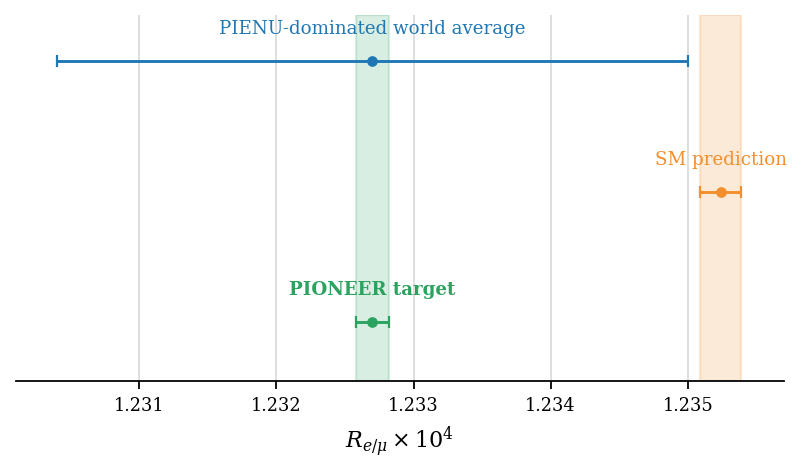

Wrote resources/figures/generated/pioneer_goal_comparison.png
Wrote resources/figures/generated/pioneer_goal_comparison.pdf


In [2]:
fig, ax = plt.subplots(figsize=(4.9, 2.85), constrained_layout=True)

x_min, x_max = 1.2301, 1.2357
ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.45, 2.35)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels([])
ax.set_xlabel(r"$R_{e/\mu}\times10^{4}$")
ax.grid(axis="x", color="0.86", linewidth=0.8)
ax.tick_params(axis="y", length=0)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

# Shaded bands show the target PIONEER precision and the SM prediction uncertainty.
ax.axvspan(r_exp - dr_goal, r_exp + dr_goal, color=colors["green"], alpha=0.18, zorder=0)
ax.axvspan(r_sm - dr_sm, r_sm + dr_sm, color=colors["orange"], alpha=0.18, zorder=0)

ax.errorbar(
    r_exp,
    2,
    xerr=dr_exp,
    fmt="o",
    color=colors["blue"],
    ecolor=colors["blue"],
    capsize=2.5,
    markersize=3.8,
    linewidth=1.3,
)
ax.errorbar(
    r_sm,
    1,
    xerr=dr_sm,
    fmt="o",
    color=colors["orange"],
    ecolor=colors["orange"],
    capsize=2.5,
    markersize=3.8,
    linewidth=1.3,
)
ax.errorbar(
    r_exp,
    0,
    xerr=dr_goal,
    fmt="o",
    color=colors["green"],
    ecolor=colors["green"],
    capsize=2.5,
    markersize=3.8,
    linewidth=1.3,
)

ax.text(
    r_exp,
    2.18,
    "PIENU-dominated world average",
    ha="center",
    va="bottom",
    fontsize=8.2,
    color=colors["blue"],
)
ax.text(
    r_sm,
    1.18,
    "SM prediction",
    ha="center",
    va="bottom",
    fontsize=8.2,
    color=colors["orange"],
)
ax.text(
    r_exp,
    0.18,
    r"PIONEER target",
    ha="center",
    va="bottom",
    fontsize=8.2,
    color=colors["green"],
    fontweight="semibold",
)

png_path = outdir / "pioneer_goal_comparison.png"
pdf_path = outdir / "pioneer_goal_comparison.pdf"
fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Wrote {png_path.relative_to(project_root)}")
print(f"Wrote {pdf_path.relative_to(project_root)}")